# Análise Financeira com Python — Desafio Final ClearBank

Notebook que lê e valida um arquivo CSV de transações bancárias, agrupa os dados por mês,
calcula métricas financeiras, sinaliza movimentações suspeitas, exibe um relatório formatado
e exporta o resultado em JSON.

**Como usar**

1. Execute as células **em ordem, do início ao fim** (no Colab: `Ambiente de execução → Executar tudo`).
2. A Célula 3 gera o arquivo `transacoes.csv`, então o notebook roda do zero, sem upload manual.
3. A Célula 9 (Execução Principal) produz o relatório completo no terminal e grava `relatorio.json`.

**Saídas geradas**

| Arquivo | Origem |
|---|---|
| `transacoes.csv` | Célula 3 |
| `relatorio.json` | Célula 9 |
| `grafico.png` | Célula 10 (opcional RO2) |
| `analise_pandas.py` | Célula 11 (opcional RO1) |

**Requisitos:** Python 3.10+. Os requisitos obrigatórios usam apenas a biblioteca padrão
(`csv`, `json`, `datetime`); `pandas` e `matplotlib` aparecem só nos requisitos opcionais.

## Decisões de implementação

Pontos em que o enunciado deixa margem e como foram resolvidos aqui:

1. **Valor médio por transação** = soma de *todos* os valores do mês (crédito + débito) ÷ quantidade
   de transações do mês. Confere com o exemplo do enunciado: (3.500,00 + 180,50) ÷ 2 = 1.840,25.
   Não é saldo ÷ quantidade.
2. **Maior / menor valor do mês**: maior e menor `valor` do mês, independentemente do tipo.
3. **Registros duplicados**: o cenário cita duplicados, mas a lista de regras de validação não pede
   deduplicação — por isso duplicados **não** são removidos (removê-los mudaria as contagens exigidas).
4. **Linha com mais de um problema** conta como **uma** linha inválida (o descarte acontece na primeira falha).
5. **Suspeita é acima do limite**: valor exatamente igual a R$ 10.000,00 não é suspeito.
6. **Suspeitas saem apenas de linhas válidas** — uma linha descartada nunca entra na lista.
7. **JSON**: valores numéricos são float puro, arredondados com `round(x, 2)`. A formatação com `R$`
   existe apenas na exibição no terminal.

## Célula 2 — Imports e constantes

Só biblioteca padrão. `LIMITE_SUSPEITO` fica no topo, como pede o R6.

In [1]:
# ===== CÉLULA 2 — Imports e constantes =====
import csv
import json
import sys
from datetime import datetime

ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
ARQUIVO_GRAFICO = "grafico.png"

FORMATO_DATA = "%Y-%m-%d"
FORMATO_MES = "%Y-%m"
TIPOS_VALIDOS = ("credito", "debito")

# R6 — acima deste valor a transação é marcada como suspeita.
LIMITE_SUSPEITO = 10000.00

print("Python:", sys.version.split()[0])
print("LIMITE_SUSPEITO:", LIMITE_SUSPEITO)

Python: 3.14.6
LIMITE_SUSPEITO: 10000.0


## Célula 3 — Geração do `transacoes.csv`

O enunciado pede o CSV criado à mão; gravá-lo por código deixa o notebook reproduzível no Colab.
O conteúdo cobre: 15 registros válidos em 3 meses, 5 inválidos (um por regra de validação) e
2 transações acima de R$ 10.000,00. Dados fictícios.

In [2]:
# ===== CÉLULA 3 — Geração do transacoes.csv =====
LINHAS_CSV = [
    "id,data,cliente_id,tipo,valor,descricao,categoria",
    # --- 15 registros válidos, distribuídos em 3 meses ---
    "1,2026-01-05,CLI001,credito,3500.00,Salário janeiro,salario",
    "2,2026-01-12,CLI002,debito,180.50,Supermercado,compra",
    "3,2026-01-18,CLI003,credito,12500.00,Venda de equipamento,transferencia",
    "4,2026-01-25,CLI001,debito,89.90,Streaming,assinatura",
    "5,2026-01-28,CLI002,debito,450.00,Conta de luz,conta",
    "6,2026-02-03,CLI001,credito,3500.00,Salário fevereiro,salario",
    "7,2026-02-10,CLI003,debito,1200.00,Aluguel,conta",
    "8,2026-02-14,CLI002,credito,15000.00,Transferência recebida,transferencia",
    "9,2026-02-20,CLI001,debito,320.75,Farmácia,compra",
    "10,2026-02-25,CLI003,debito,99.90,Assinatura anual,assinatura",
    "11,2026-03-01,CLI001,credito,3500.00,Salário março,salario",
    "12,2026-03-07,CLI002,debito,760.40,Material de escritório,compra",
    "13,2026-03-15,CLI003,credito,2200.00,Projeto freelance,transferencia",
    "14,2026-03-22,CLI002,debito,150.00,Internet,conta",
    "15,2026-03-30,CLI001,debito,58.30,Cafeteria,compra",
    # --- 5 registros inválidos, um para cada regra do R2 ---
    "abc,2026-01-09,CLI004,debito,120.00,ID não numérico,compra",
    "17,2026-02-05,,debito,200.00,Cliente vazio,transferencia",
    "18,05/01/2026,CLI002,credito,900.00,Data fora do padrão,salario",
    "19,2026-03-11,CLI003,estorno,300.00,Tipo inválido,compra",
    "20,2026-03-18,CLI001,debito,abc,Valor não numérico,compra",
]

with open(ARQUIVO_CSV, "w", encoding="utf-8", newline="") as arquivo:
    arquivo.write("\n".join(LINHAS_CSV) + "\n")

print(f"{ARQUIVO_CSV} gravado com {len(LINHAS_CSV) - 1} linhas de dados (sem contar o cabeçalho).")

transacoes.csv gravado com 20 linhas de dados (sem contar o cabeçalho).


## Célula 4 — Funções de validação (R2, R3, R8)

Cada regra do enunciado vira uma função pequena. `validar_transacao()` só orquestra as regras e
devolve o registro limpo ou `None` — quem retorna `None` é descartado silenciosamente.
As conversões de `valor` e `data` capturam `ValueError` (situações 2 e 3 do R8).

In [3]:
# ===== CÉLULA 4 — Funções de validação =====

def validar_id(id_texto):
    """Retorna o id como int; None se estiver vazio ou não for numérico."""
    id_texto = (id_texto or "").strip()
    if not id_texto.isdigit():
        return None
    return int(id_texto)


def validar_data(data_texto):
    """Converte AAAA-MM-DD em datetime; None se o formato for inválido (R4/R8)."""
    data_texto = (data_texto or "").strip()
    if not data_texto:
        return None
    try:
        return datetime.strptime(data_texto, FORMATO_DATA)
    except ValueError:
        # Data mal formatada não pode derrubar o programa: descarta a linha.
        return None


def validar_valor(valor_texto):
    """Converte para float; None se não for numérico ou se for menor/igual a zero (R2/R8)."""
    valor_texto = (valor_texto or "").strip()
    try:
        valor = float(valor_texto)
    except ValueError:
        return None
    return valor if valor > 0 else None


def montar_registro(id_transacao, data, cliente_id, tipo, valor, linha):
    """Monta o dicionário limpo de uma transação já validada."""
    return {
        "id": id_transacao,
        "data": data,
        "mes": data.strftime(FORMATO_MES),
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": (linha.get("descricao") or "").strip(),
        "categoria": (linha.get("categoria") or "").strip(),
    }


def validar_transacao(linha):
    """Valida uma única linha bruta do CSV e devolve o registro limpo, ou None."""
    id_transacao = validar_id(linha.get("id"))
    data = validar_data(linha.get("data"))
    valor = validar_valor(linha.get("valor"))
    cliente_id = (linha.get("cliente_id") or "").strip()
    tipo = (linha.get("tipo") or "").strip().lower()

    if id_transacao is None or data is None or valor is None:
        return None
    if not cliente_id or tipo not in TIPOS_VALIDOS:
        return None
    return montar_registro(id_transacao, data, cliente_id, tipo, valor, linha)


# --- Teste rápido ---
linha_ok = {"id": "1", "data": "2026-01-05", "cliente_id": "CLI001", "tipo": "credito",
            "valor": "3500.00", "descricao": "Salário janeiro", "categoria": "salario"}

print("linha válida            ->", validar_transacao(linha_ok) is not None)
print("id não numérico         ->", validar_id("abc"))
print("data fora do padrão     ->", validar_data("05/01/2026"))
print("valor não numérico      ->", validar_valor("abc"))
print("valor zero/negativo     ->", validar_valor("-10"), validar_valor("0"))
print("cliente_id vazio        ->", validar_transacao({**linha_ok, "cliente_id": ""}))
print("tipo inválido           ->", validar_transacao({**linha_ok, "tipo": "estorno"}))
print("mês extraído da data    ->", validar_transacao(linha_ok)["mes"])

linha válida            -> True
id não numérico         -> None
data fora do padrão     -> None
valor não numérico      -> None
valor zero/negativo     -> None None
cliente_id vazio        -> None
tipo inválido           -> None
mês extraído da data    -> 2026-01


## Célula 5 — Leitura do CSV e processamento (R1, R2, R6, R8)

`ler_transacoes()` usa `csv.DictReader` dentro de um `with open(...)` e captura `FileNotFoundError`
(situação 1 do R8). `processar_transacoes()` percorre as linhas, descarta as inválidas em silêncio e
já separa as suspeitas no mesmo laço.

In [4]:
# ===== CÉLULA 5 — Leitura e processamento =====

def ler_transacoes(caminho=ARQUIVO_CSV):
    """Lê o CSV com csv.DictReader e devolve a lista de transações brutas (R1/R8)."""
    try:
        with open(caminho, newline="", encoding="utf-8") as arquivo:
            return list(csv.DictReader(arquivo))
    except FileNotFoundError:
        print(f"Arquivo não encontrado: {caminho}. Execute a Célula 3 para gerá-lo.")
        return []


def processar_transacoes(linhas):
    """Valida linha a linha e separa as válidas e as suspeitas (R2/R6)."""
    validas = []
    suspeitas = []
    for linha in linhas:
        transacao = validar_transacao(linha)
        if transacao is None:
            continue  # linha inválida: descarte silencioso, o processamento segue
        validas.append(transacao)
        if transacao["valor"] > LIMITE_SUSPEITO:
            suspeitas.append(transacao)
    return validas, suspeitas


def exibir_resumo_limpeza(total_lidas, total_validas):
    """Imprime o resumo da limpeza exigido no R2."""
    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {total_validas}")
    print(f"Linhas inválidas: {total_lidas - total_validas}")


# --- Teste rápido ---
linhas_teste = ler_transacoes()
validas_teste, suspeitas_teste = processar_transacoes(linhas_teste)

exibir_resumo_limpeza(len(linhas_teste), len(validas_teste))
print("Suspeitas encontradas:", len(suspeitas_teste))
print("Arquivo inexistente ->", ler_transacoes("arquivo_que_nao_existe.csv"))

Total de linhas lidas: 20
Linhas válidas: 15
Linhas inválidas: 5
Suspeitas encontradas: 2
Arquivo não encontrado: arquivo_que_nao_existe.csv. Execute a Célula 3 para gerá-lo.
Arquivo inexistente -> []


## Célula 6 — Agrupamento mensal e métricas (R4, R5)

O agrupamento usa um dicionário com o mês (`AAAA-MM`) como chave. `gerar_relatorio()` monta a
estrutura final já no formato do JSON, incluindo o período e os dias entre a transação mais antiga
e a mais recente (R4).

In [5]:
# ===== CÉLULA 6 — Agrupamento mensal e métricas =====

def acumular_mes(resumo, transacao):
    """Soma uma transação no acumulador do mês correspondente (R5)."""
    mes = resumo.setdefault(transacao["mes"], {
        "quantidade": 0,
        "total_credito": 0.0,
        "total_debito": 0.0,
        "valores": [],
    })
    mes["quantidade"] += 1
    mes["valores"].append(transacao["valor"])
    chave = "total_credito" if transacao["tipo"] == "credito" else "total_debito"
    mes[chave] += transacao["valor"]
    return resumo


def fechar_metricas(dados):
    """Calcula saldo, média, maior e menor valor do mês e arredonda em 2 casas (R5)."""
    valores = dados.pop("valores")
    dados["saldo"] = dados["total_credito"] - dados["total_debito"]
    dados["media"] = sum(valores) / len(valores)
    dados["maior_valor"] = max(valores)
    dados["menor_valor"] = min(valores)
    return {chave: round(valor, 2) if isinstance(valor, float) else valor
            for chave, valor in dados.items()}


def calcular_resumo_mensal(transacoes):
    """Agrupa por mês (AAAA-MM) e devolve as métricas em ordem cronológica."""
    resumo = {}
    for transacao in transacoes:
        acumular_mes(resumo, transacao)
    return {mes: fechar_metricas(dados) for mes, dados in sorted(resumo.items())}


def calcular_periodo(transacoes):
    """Data mais antiga, mais recente e quantos dias se passaram entre elas (R4)."""
    if not transacoes:
        return {"data_inicial": None, "data_final": None, "dias_entre": 0}
    datas = [transacao["data"] for transacao in transacoes]
    inicial, final = min(datas), max(datas)
    return {
        "data_inicial": inicial.strftime(FORMATO_DATA),
        "data_final": final.strftime(FORMATO_DATA),
        "dias_entre": (final - inicial).days,
    }


def resumir_suspeita(transacao):
    """Reduz a transação suspeita aos campos exigidos no R6/R7."""
    return {
        "id": transacao["id"],
        "cliente_id": transacao["cliente_id"],
        "data": transacao["data"].strftime(FORMATO_DATA),
        "valor": round(transacao["valor"], 2),
    }


def gerar_relatorio(transacoes, total_lidas, suspeitas):
    """Monta o dicionário final do relatório, pronto para virar JSON (R5/R7)."""
    return {
        "gerado_em": datetime.now().strftime(FORMATO_DATA),
        "total_transacoes_validas": len(transacoes),
        "total_transacoes_invalidas": total_lidas - len(transacoes),
        "resumo_mensal": calcular_resumo_mensal(transacoes),
        "transacoes_suspeitas": [resumir_suspeita(t) for t in suspeitas],
        "periodo": calcular_periodo(transacoes),
    }


# --- Teste rápido ---
relatorio_teste = gerar_relatorio(validas_teste, len(linhas_teste), suspeitas_teste)

print("Meses encontrados:", list(relatorio_teste["resumo_mensal"]))
print("Período:", relatorio_teste["periodo"])
print("Métricas de 2026-01:", relatorio_teste["resumo_mensal"]["2026-01"])

# Confere a definição de média com o exemplo do enunciado: (3500,00 + 180,50) / 2 = 1840,25
exemplo_enunciado = [
    {"mes": "2026-01", "tipo": "credito", "valor": 3500.00, "data": datetime(2026, 1, 5)},
    {"mes": "2026-01", "tipo": "debito", "valor": 180.50, "data": datetime(2026, 1, 12)},
]
print("Média do exemplo do enunciado:", calcular_resumo_mensal(exemplo_enunciado)["2026-01"]["media"])

Meses encontrados: ['2026-01', '2026-02', '2026-03']
Período: {'data_inicial': '2026-01-05', 'data_final': '2026-03-30', 'dias_entre': 84}
Métricas de 2026-01: {'quantidade': 5, 'total_credito': 16000.0, 'total_debito': 720.4, 'saldo': 15279.6, 'media': 3344.08, 'maior_valor': 12500.0, 'menor_valor': 89.9}
Média do exemplo do enunciado: 1840.25


## Célula 7 — Exibição formatada no terminal (R6, R9)

`formatar_moeda()` isola o padrão brasileiro (`R$ 1.234,56`). A impressão é dividida em cabeçalho,
resumo mensal e suspeitas, para nenhuma função ficar longa demais.

In [6]:
# ===== CÉLULA 7 — Formatação e exibição =====

def formatar_moeda(valor):
    """Formata um número no padrão brasileiro: R$ 1.234,56 (R9)."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def exibir_cabecalho(relatorio):
    """Imprime período analisado e totais de válidas/inválidas (R9)."""
    periodo = relatorio["periodo"]
    print("===== ANÁLISE FINANCEIRA — CLEARBANK =====")
    print(f"Gerado em: {relatorio['gerado_em']}")
    print(f"Período analisado: {periodo['data_inicial']} -> {periodo['data_final']} "
          f"({periodo['dias_entre']} dias)")
    print(f"Transações válidas: {relatorio['total_transacoes_validas']}")
    print(f"Transações inválidas: {relatorio['total_transacoes_invalidas']}")


def exibir_mes(mes, dados):
    """Imprime o bloco de métricas de um mês (R5)."""
    print(f"\nMês: {mes}")
    print(f"  Transações: {dados['quantidade']}")
    print(f"  Total crédito: {formatar_moeda(dados['total_credito'])}")
    print(f"  Total débito:  {formatar_moeda(dados['total_debito'])}")
    print(f"  Saldo:         {formatar_moeda(dados['saldo'])}")
    print(f"  Média:         {formatar_moeda(dados['media'])}")
    print(f"  Maior valor:   {formatar_moeda(dados['maior_valor'])}")
    print(f"  Menor valor:   {formatar_moeda(dados['menor_valor'])}")


def exibir_suspeitas(suspeitas):
    """Lista as transações acima do LIMITE_SUSPEITO (R6)."""
    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    if not suspeitas:
        print("Nenhuma transação suspeita encontrada.")
        return
    for suspeita in suspeitas:
        print(f"ID: {suspeita['id']} | Cliente: {suspeita['cliente_id']} | "
              f"Data: {suspeita['data']} | Valor: {formatar_moeda(suspeita['valor'])}")


def exibir_relatorio(relatorio):
    """Imprime o relatório completo, seção por seção (R9)."""
    exibir_cabecalho(relatorio)
    print("\n===== RELATÓRIO MENSAL =====")
    for mes, dados in relatorio["resumo_mensal"].items():
        exibir_mes(mes, dados)
    exibir_suspeitas(relatorio["transacoes_suspeitas"])


# --- Teste rápido ---
print("Formatação de moeda:", formatar_moeda(1234.5), "|", formatar_moeda(15000.0), "|", formatar_moeda(0.5))
print()
exibir_mes("2026-01", relatorio_teste["resumo_mensal"]["2026-01"])
exibir_suspeitas(relatorio_teste["transacoes_suspeitas"])
exibir_suspeitas([])

Formatação de moeda: R$ 1.234,50 | R$ 15.000,00 | R$ 0,50


Mês: 2026-01
  Transações: 5
  Total crédito: R$ 16.000,00
  Total débito:  R$ 720,40
  Saldo:         R$ 15.279,60
  Média:         R$ 3.344,08
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 89,90

===== TRANSAÇÕES SUSPEITAS =====
ID: 3 | Cliente: CLI003 | Data: 2026-01-18 | Valor: R$ 12.500,00
ID: 8 | Cliente: CLI002 | Data: 2026-02-14 | Valor: R$ 15.000,00

===== TRANSAÇÕES SUSPEITAS =====
Nenhuma transação suspeita encontrada.


## Célula 8 — Exportação em JSON (R7)

`json.dump(..., ensure_ascii=False, indent=2)` mantém os acentos e deixa o arquivo legível.
Os valores vão como float puro — a formatação `R$` só existe no terminal.

In [7]:
# ===== CÉLULA 8 — Exportação em JSON =====

def salvar_json(relatorio, caminho=ARQUIVO_JSON):
    """Salva o relatório em relatorio.json com acentos e indentação (R7)."""
    try:
        with open(caminho, "w", encoding="utf-8") as arquivo:
            json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)
    except OSError as erro:
        print(f"Não foi possível salvar {caminho}: {erro}")
        return False
    print(f"Relatório salvo em: {caminho}")
    return True


# --- Teste rápido ---
salvar_json(relatorio_teste)

with open(ARQUIVO_JSON, encoding="utf-8") as arquivo:
    conteudo = json.load(arquivo)

print("Chaves do JSON:", list(conteudo))
print("Meses no JSON:", list(conteudo["resumo_mensal"]))
print("Tipo dos valores (float puro):", type(conteudo["resumo_mensal"]["2026-01"]["saldo"]).__name__)
print("Suspeitas no JSON:", conteudo["transacoes_suspeitas"])

Relatório salvo em: relatorio.json
Chaves do JSON: ['gerado_em', 'total_transacoes_validas', 'total_transacoes_invalidas', 'resumo_mensal', 'transacoes_suspeitas', 'periodo']
Meses no JSON: ['2026-01', '2026-02', '2026-03']
Tipo dos valores (float puro): float
Suspeitas no JSON: [{'id': 3, 'cliente_id': 'CLI003', 'data': '2026-01-18', 'valor': 12500.0}, {'id': 8, 'cliente_id': 'CLI002', 'data': '2026-02-14', 'valor': 15000.0}]


## Célula 9 — Execução Principal

Chama tudo na ordem: leitura → validação → métricas → relatório no terminal → JSON.

In [8]:
# ===== CÉLULA 9 — EXECUÇÃO PRINCIPAL =====

def executar_analise(caminho_csv=ARQUIVO_CSV, caminho_json=ARQUIVO_JSON):
    """Orquestra a análise completa e devolve o relatório gerado (R1 a R9)."""
    linhas = ler_transacoes(caminho_csv)
    validas, suspeitas = processar_transacoes(linhas)

    print("===== RESUMO DA LIMPEZA =====")
    exibir_resumo_limpeza(len(linhas), len(validas))

    if not validas:
        print("\nNenhuma transação válida para analisar.")
        return None

    relatorio = gerar_relatorio(validas, len(linhas), suspeitas)
    print()
    exibir_relatorio(relatorio)
    print()
    salvar_json(relatorio, caminho_json)
    return relatorio


relatorio_final = executar_analise()

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 20
Linhas válidas: 15
Linhas inválidas: 5

===== ANÁLISE FINANCEIRA — CLEARBANK =====
Gerado em: 2026-08-28
Período analisado: 2026-01-05 -> 2026-03-30 (84 dias)
Transações válidas: 15
Transações inválidas: 5

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 5
  Total crédito: R$ 16.000,00
  Total débito:  R$ 720,40
  Saldo:         R$ 15.279,60
  Média:         R$ 3.344,08
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 89,90

Mês: 2026-02
  Transações: 5
  Total crédito: R$ 18.500,00
  Total débito:  R$ 1.620,65
  Saldo:         R$ 16.879,35
  Média:         R$ 4.024,13
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 99,90

Mês: 2026-03
  Transações: 5
  Total crédito: R$ 5.700,00
  Total débito:  R$ 968,70
  Saldo:         R$ 4.731,30
  Média:         R$ 1.333,74
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 58,30

===== TRANSAÇÕES SUSPEITAS =====
ID: 3 | Cliente: CLI003 | Data: 2026-01-18 | Valor: R$ 12.500,00
ID: 

## Célula 10 — RO2: gráfico com matplotlib

Gráfico de barras do saldo mensal (crédito − débito), salvo como `grafico.png`, com título,
rótulos nos dois eixos e legenda.

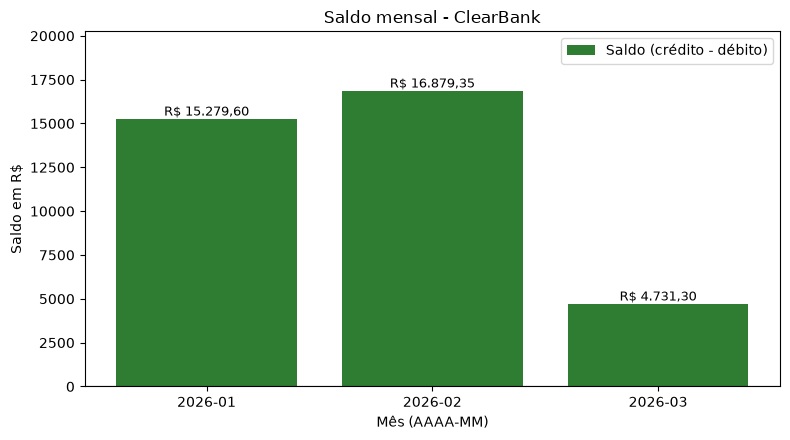

Gráfico salvo em: grafico.png


In [9]:
# ===== CÉLULA 10 — (RO2) Gráfico do saldo mensal =====
%matplotlib inline
import matplotlib.pyplot as plt


def gerar_grafico_saldo(relatorio, caminho=ARQUIVO_GRAFICO):
    """Gera o gráfico de barras do saldo mensal e salva como grafico.png (RO2)."""
    meses = list(relatorio["resumo_mensal"])
    saldos = [relatorio["resumo_mensal"][mes]["saldo"] for mes in meses]

    figura, eixo = plt.subplots(figsize=(8, 4.5))
    eixo.bar(meses, saldos, color="#2e7d32", label="Saldo (crédito - débito)")
    eixo.axhline(0, color="#444444", linewidth=0.8)
    eixo.set_title("Saldo mensal - ClearBank")
    eixo.set_xlabel("Mês (AAAA-MM)")
    eixo.set_ylabel("Saldo em R$")
    eixo.legend()

    for posicao, saldo in enumerate(saldos):
        eixo.text(posicao, saldo, formatar_moeda(saldo), ha="center", va="bottom", fontsize=9)

    margem = max(abs(min(saldos)), abs(max(saldos))) * 0.20
    eixo.set_ylim(min(0, min(saldos) - margem), max(saldos) + margem)
    figura.tight_layout()
    figura.savefig(caminho, dpi=150)
    plt.show()
    return caminho


print("Gráfico salvo em:", gerar_grafico_saldo(relatorio_final))

## Célula 11 — RO1: versão com pandas

O enunciado pede a versão pandas em arquivo separado. A célula abaixo grava `analise_pandas.py`
e a seguinte executa o arquivo, mostrando o resultado e a comparação com a solução nativa.

In [10]:
%%writefile analise_pandas.py
"""RO1 - Versao alternativa da leitura e do agrupamento usando pandas.

Le o mesmo transacoes.csv, aplica as mesmas regras de validacao, agrupa por mes
com groupby e compara os numeros com os do relatorio.json gerado pelo notebook.

Uso: python analise_pandas.py
"""

import json
import sys
from pathlib import Path

import pandas as pd

ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
LIMITE_SUSPEITO = 10000.00
TIPOS_VALIDOS = ("credito", "debito")
CAMPOS = ["quantidade", "total_credito", "total_debito", "saldo", "media", "maior_valor", "menor_valor"]


def carregar(caminho=ARQUIVO_CSV):
    """Le o CSV como texto para validar os campos do mesmo jeito que a solucao nativa."""
    try:
        return pd.read_csv(caminho, dtype=str)
    except FileNotFoundError:
        print(f"Arquivo nao encontrado: {caminho}")
        sys.exit(1)


def limpar(bruto):
    """Aplica as 5 regras de validacao e devolve so as linhas validas."""
    dados = bruto.copy()
    dados["id_num"] = pd.to_numeric(dados["id"], errors="coerce")
    dados["data_dt"] = pd.to_datetime(dados["data"], format="%Y-%m-%d", errors="coerce")
    dados["valor_num"] = pd.to_numeric(dados["valor"], errors="coerce")
    dados["tipo"] = dados["tipo"].fillna("").astype(str).str.strip().str.lower()
    dados["cliente_id"] = dados["cliente_id"].fillna("").astype(str).str.strip()

    valido = (
        dados["id_num"].notna()
        & dados["data_dt"].notna()
        & dados["valor_num"].gt(0)
        & dados["cliente_id"].ne("")
        & dados["tipo"].isin(TIPOS_VALIDOS)
    )
    return dados[valido].copy()


def resumir(validas):
    """Agrupa por mes com groupby e calcula as mesmas metricas do relatorio nativo."""
    validas["mes"] = validas["data_dt"].dt.strftime("%Y-%m")
    agregado = validas.groupby("mes")["valor_num"].agg(["count", "mean", "max", "min"])
    credito = validas[validas["tipo"] == "credito"].groupby("mes")["valor_num"].sum()
    debito = validas[validas["tipo"] == "debito"].groupby("mes")["valor_num"].sum()

    resumo = pd.DataFrame({
        "quantidade": agregado["count"],
        "total_credito": credito.reindex(agregado.index, fill_value=0.0),
        "total_debito": debito.reindex(agregado.index, fill_value=0.0),
        "media": agregado["mean"],
        "maior_valor": agregado["max"],
        "menor_valor": agregado["min"],
    })
    resumo["saldo"] = resumo["total_credito"] - resumo["total_debito"]
    return resumo[CAMPOS].round(2).sort_index()


def comparar(resumo, caminho=ARQUIVO_JSON):
    """Compara os numeros do pandas com os do relatorio.json (solucao nativa)."""
    if not Path(caminho).exists():
        print(f"{caminho} nao encontrado - rode o notebook antes para comparar.")
        return
    nativo = json.loads(Path(caminho).read_text(encoding="utf-8"))["resumo_mensal"]

    if set(nativo) != set(resumo.index):
        print(f"Meses diferentes: nativo={sorted(nativo)} pandas={sorted(resumo.index)}")
        return

    divergencias = 0
    for mes, linha in resumo.iterrows():
        for campo in CAMPOS:
            valor_pandas = round(float(linha[campo]), 2)
            valor_nativo = round(float(nativo[mes][campo]), 2)
            if abs(valor_pandas - valor_nativo) > 0.01:
                divergencias += 1
                print(f"DIVERGENCIA {mes}.{campo}: pandas={valor_pandas} nativo={valor_nativo}")

    if divergencias == 0:
        print("OK - todos os valores batem com a solucao nativa (csv + datetime).")
    else:
        print(f"{divergencias} divergencia(s) encontrada(s).")


def main():
    bruto = carregar()
    validas = limpar(bruto)

    print("===== RO1 - ANALISE COM PANDAS =====")
    print(f"Total de linhas lidas: {len(bruto)}")
    print(f"Linhas validas: {len(validas)}")
    print(f"Linhas invalidas: {len(bruto) - len(validas)}")

    resumo = resumir(validas)
    print("\n----- Resumo mensal (groupby) -----")
    print(resumo.to_string())

    suspeitas = validas[validas["valor_num"] > LIMITE_SUSPEITO]
    print(f"\n----- Transacoes suspeitas (acima de {LIMITE_SUSPEITO:.2f}) -----")
    print(suspeitas[["id", "data", "cliente_id", "valor_num"]].to_string(index=False))

    print("\n----- Comparacao com a solucao nativa -----")
    comparar(resumo)


if __name__ == "__main__":
    main()

Overwriting analise_pandas.py


In [11]:
# ===== CÉLULA 11 — (RO1) Executa a versão pandas e mostra o resultado =====
import subprocess

resultado = subprocess.run(
    [sys.executable, "analise_pandas.py"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)

print(resultado.stdout)
if resultado.returncode != 0:
    print("STDERR:", resultado.stderr)

===== RO1 - ANALISE COM PANDAS =====
Total de linhas lidas: 20
Linhas validas: 15
Linhas invalidas: 5

----- Resumo mensal (groupby) -----
         quantidade  total_credito  total_debito     saldo    media  maior_valor  menor_valor
mes                                                                                          
2026-01           5        16000.0        720.40  15279.60  3344.08      12500.0         89.9
2026-02           5        18500.0       1620.65  16879.35  4024.13      15000.0         99.9
2026-03           5         5700.0        968.70   4731.30  1333.74       3500.0         58.3

----- Transacoes suspeitas (acima de 10000.00) -----
id       data cliente_id  valor_num
 3 2026-01-18     CLI003    12500.0
 8 2026-02-14     CLI002    15000.0

----- Comparacao com a solucao nativa -----
OK - todos os valores batem com a solucao nativa (csv + datetime).



## Checklist de requisitos

| Requisito | Onde é atendido |
|---|---|
| R1 — CSV com módulo nativo (`csv.DictReader`, `with open`, `FileNotFoundError`) | Célula 5 — `ler_transacoes()` |
| R2 — Validação, descarte silencioso e resumo da limpeza | Células 4 e 5 — `validar_transacao()`, `processar_transacoes()`, `exibir_resumo_limpeza()` |
| R3 — Organização em funções (5 principais + auxiliares) | Células 4 a 9 |
| R4 — Datas com `strptime`/`strftime` e dias entre a mais antiga e a mais recente | Células 4 e 6 — `validar_data()`, `calcular_periodo()` |
| R5 — Agrupamento mensal e as 7 métricas | Célula 6 — `calcular_resumo_mensal()` |
| R6 — `LIMITE_SUSPEITO` e lista de suspeitas | Células 2, 5 e 7 |
| R7 — `relatorio.json` com `ensure_ascii=False, indent=2` | Célula 8 — `salvar_json()` |
| R8 — `try/except` específico em 3 situações | `FileNotFoundError` (Célula 5), `ValueError` em `float` e em `strptime` (Célula 4) |
| R9 — Exibição formatada, `R$`, separadores, período e totais | Célula 7 — `formatar_moeda()`, `exibir_relatorio()` |
| RO1 — pandas em arquivo separado com comparação | Célula 11 — `analise_pandas.py` |
| RO2 — `grafico.png` com título, rótulos e legenda | Célula 10 — `gerar_grafico_saldo()` |